# ECG Baseline Model
An ECG-only 1D CNN for HFrEF prediction. The processed data is split at the subject level to prevent data leakage and handle class imbalance using a weighted loss function.

The input now has 4 channels (APEX, LLSB, LUSB, RUSB), with 30 seconds for each channel. Run the preprocessing notebook first; it prepares the test set too.

In [1]:
import os
import sys
import json
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
from tqdm import tqdm

from torch.utils.data import DataLoader

PROJECT_DIR = os.path.abspath('..') if os.path.isdir('../src') else os.path.abspath('.')
if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)
from src.data_loader import ProcessedCardioDataset, get_dataloaders
from src.ecg_model import ECG_Encoder
from src.preprocessing import CHANNEL_ORDER, ECG_FS, ECG_SAMPLES

# use the same seed for each run
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

PROCESSED_DIR = os.path.join(PROJECT_DIR, 'data/processed/patient_4ch/development')
metadata_path = os.path.join(PROCESSED_DIR, 'processed_metadata.csv')
if not os.path.isfile(metadata_path):
    raise FileNotFoundError('Run 1_preprocessing.ipynb first to save the patient tensors.')
metadata = pd.read_csv(metadata_path, dtype={'Patient_ID': str})

# split data ensuring all 4 channels from the same patient stay together
# use one of the original folds for validation, and the other 4 for training
VALIDATION_FOLD = 0
assert metadata['Patient_ID'].is_unique
assert metadata['Fold'].isin(range(5)).all()

train_df = metadata[metadata['Fold'] != VALIDATION_FOLD].reset_index(drop=True)
val_df = metadata[metadata['Fold'] == VALIDATION_FOLD].reset_index(drop=True)

assert set(train_df['Patient_ID']).isdisjoint(val_df['Patient_ID'])
assert set(train_df['Label']) == {0, 1}
assert set(val_df['Label']) == {0, 1}

print(f"Training patients: {len(train_df)}")
print(f"Validation patients: {len(val_df)}")

Training patients: 400
Validation patients: 100


C:\Users\BluRay\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Initialize Dataloaders and Model
PyTorch `.pt` tensors are directly loaded from the disk.

Each ECG tensor is `(4, 15000)` before batching. The model now has residual convolution blocks, batch normalization, and dropout. We also use average and max pooling before the final classifier.

In [2]:
# Using unsegmented data for training and validation
# each input contains all 4 channels for one patient
batch_size = 16

# initialize custom dataloaders
train_loader, val_loader = get_dataloaders(
    train_df, val_df, data_dir=PROCESSED_DIR, batch_size=batch_size,
    modality='ecg', seed=SEED,
)

# setup device for GPU acceleration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# initialize model
model_config = {'in_channels': 4, 'feature_dim': 128, 'dropout': 0.3}
ecg_model = ECG_Encoder(**model_config).to(device)

sample_ecg, sample_labels = next(iter(val_loader))
assert sample_ecg.shape[1:] == (4, ECG_SAMPLES)

print(f"DataLoaders ready. Training batches: {len(train_loader)}")
print(f"Model initialized on device: {device}")
print(f"Input shape: {sample_ecg.shape}")

DataLoaders ready. Training batches: 25
Model initialized on device: cuda
Input shape: torch.Size([16, 4, 15000])


## Training Loop
Since we have few HFrEF subjects (440 Non-HFrEF to 60 HFrEF across all 5 folds), we're using Focal Loss.

Binary Cross Entropy with Logits Loss (`BCEWithLogitsLoss`) was previously used. A positive weight of ~7.3 was applied to the loss function to penalize the model heavily if it missed an HFrEF case.

We calculate the weight using the training patients only. We also use AdamW, reduce the learning rate if validation AUROC stops improving, and stop early after 10 epochs without improvement.

### Focal Loss
Focal Loss focuses on hard-to-classify examples, which is beneficial in our case with imbalanced classes. The formula is:
$$ FL(p_t) = -\alpha_t (1 - p_t)^\gamma \log(p_t) $$
Where:
- $p_t$ is the model's estimated probability for the true class.
- $\alpha_t$ is the balancing factor for the true class.
- $\gamma$ is the focusing parameter that reduces the loss contribution from easy examples.

In [3]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.88, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        # standard BCE loss
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        
        # get raw probabilities
        probs = torch.sigmoid(inputs)
        
        # pt is the probability of the true class
        pt = torch.where(targets == 1, probs, 1 - probs)
        
        # apply class weighting
        alpha_t = torch.where(targets == 1, self.alpha, 1 - self.alpha)
        
        # Focal Loss formula
        focal_loss = alpha_t * (1 - pt) ** self.gamma * bce_loss
        
        return focal_loss.mean()

In [4]:
MODEL_DIR = os.path.join(PROJECT_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True) # create models directory if it doesn't exist

# manually set hyperparameters
num_epochs = 50
learning_rate = 1e-3
weight_decay = 1e-4
patience = 10

# initialize Focal Loss instead of BCEWithLogitsLoss
focal_alpha = float((train_df['Label'] == 0).mean())
criterion = FocalLoss(alpha=focal_alpha, gamma=2.0).to(device)
optimizer = optim.AdamW(ecg_model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

best_auroc = -float('inf')
epochs_without_improvement = 0
history = []
MODEL_SAVE_PATH = os.path.join(MODEL_DIR, f'best_ecg_4ch_fold{VALIDATION_FOLD}.pt')

for epoch in range(num_epochs):
    # training
    ecg_model.train()
    train_loss = 0.0

    for ecg, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        ecg = ecg.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)
        outputs = ecg_model(ecg)
        loss = criterion(outputs, labels)

        if not torch.isfinite(loss):
            raise ValueError("Training loss is not finite.")
        loss.backward()
        nn.utils.clip_grad_norm_(ecg_model.parameters(), max_norm=1.0, error_if_nonfinite=True)
        optimizer.step()
        train_loss += loss.item() * ecg.size(0)

    epoch_train_loss = train_loss / len(train_loader.dataset)

    # validation
    ecg_model.eval()
    val_loss = 0.0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for ecg, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            ecg = ecg.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = ecg_model(ecg)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * ecg.size(0)

            # sigmoid to convert raw logits to probabilities
            preds = torch.sigmoid(outputs)
            all_labels.extend(labels.cpu().numpy().ravel())
            all_preds.extend(preds.cpu().numpy().ravel())

    epoch_val_loss = val_loss / len(val_loader.dataset)

    # calculate metrics
    auroc = roc_auc_score(all_labels, all_preds)
    auprc = average_precision_score(all_labels, all_preds)

    print(f"Epoch {epoch+1} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | AUROC: {auroc:.4f} | AUPRC: {auprc:.4f}")

    history.append({
        'epoch': epoch + 1,
        'train_loss': epoch_train_loss,
        'val_loss': epoch_val_loss,
        'val_auroc': auroc,
        'val_auprc': auprc,
        'lr': optimizer.param_groups[0]['lr'],
    })
    scheduler.step(auroc)

    # save model if AUROC improves
    if auroc > best_auroc:
        print(f"Validation AUROC improved from {best_auroc:.4f} to {auroc:.4f}. Saving improved model.")
        best_auroc = auroc
        epochs_without_improvement = 0
        torch.save(ecg_model.state_dict(), MODEL_SAVE_PATH) # save state_dict() instead of the whole model
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping. Best validation AUROC: {best_auroc:.4f}")
            break

# keep the best weights for evaluation
ecg_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device, weights_only=True))
ecg_model.eval()

history = pd.DataFrame(history)
history.to_csv(MODEL_SAVE_PATH.replace('.pt', '.history.csv'), index=False)

Epoch 1/50 [Val]: 100%|██████████| 7/7 [00:00<00:00, 15.69it/s]


Epoch 1 | Train Loss: 0.0524 | Val Loss: 0.0304 | AUROC: 0.7879 | AUPRC: 0.3538
Validation AUROC improved from -inf to 0.7879. Saving improved model.


Epoch 2/50 [Val]: 100%|██████████| 7/7 [00:00<00:00, 35.62it/s]


Epoch 2 | Train Loss: 0.0324 | Val Loss: 0.0323 | AUROC: 0.8788 | AUPRC: 0.4616
Validation AUROC improved from 0.7879 to 0.8788. Saving improved model.


Epoch 3/50 [Val]: 100%|██████████| 7/7 [00:00<00:00, 29.64it/s]


...

Epoch 31 | Train Loss: 0.0001 | Val Loss: 0.0477 | AUROC: 0.9413 | AUPRC: 0.7060


Epoch 32/50 [Val]: 100%|██████████| 7/7 [00:00<00:00, 30.50it/s]


Epoch 32 | Train Loss: 0.0002 | Val Loss: 0.0484 | AUROC: 0.9422 | AUPRC: 0.7081


Epoch 33/50 [Val]: 100%|██████████| 7/7 [00:00<00:00, 32.63it/s]

Epoch 33 | Train Loss: 0.0001 | Val Loss: 0.0471 | AUROC: 0.9422 | AUPRC: 0.7038
Early stopping. Best validation AUROC: 0.9564


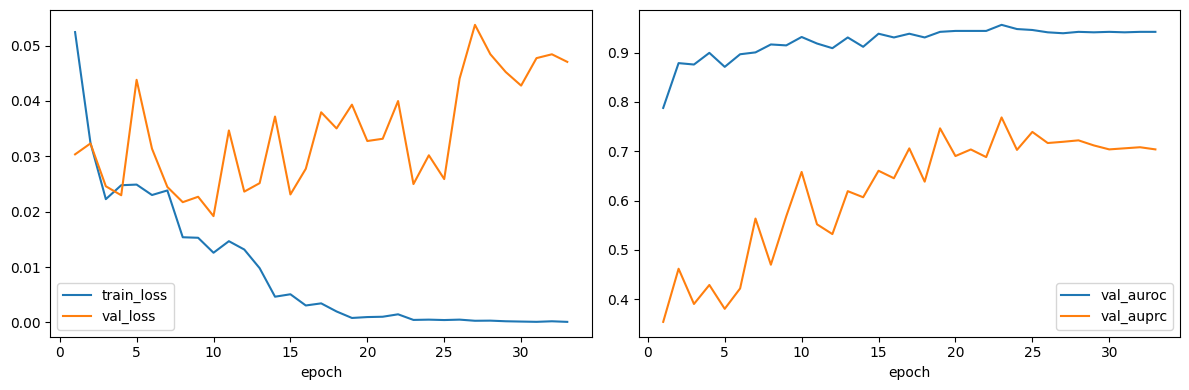

In [5]:
# plot the training and validation results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history.plot(x='epoch', y=['train_loss', 'val_loss'], ax=axes[0])
history.plot(x='epoch', y=['val_auroc', 'val_auprc'], ax=axes[1])
plt.tight_layout()
plt.show()

## Model Evaluation
We choose the threshold using the validation set, then keep it the same for the test set.

Optimal Probability Cutoff: 0.5117
Max F1-Score: 0.7097

Classification Report:
              precision    recall  f1-score   support

   Non-HFrEF       0.99      0.91      0.95        88
       HFrEF       0.58      0.92      0.71        12

    accuracy                           0.91       100
   macro avg       0.78      0.91      0.83       100
weighted avg       0.94      0.91      0.92       100

Confusion Matrix:
[[80  8]
 [ 1 11]]


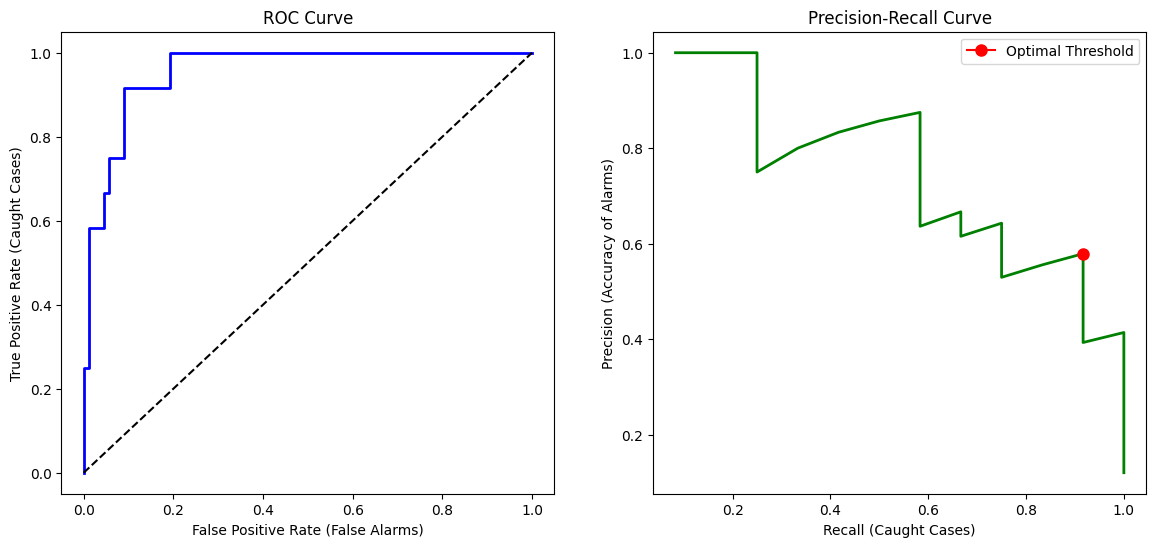

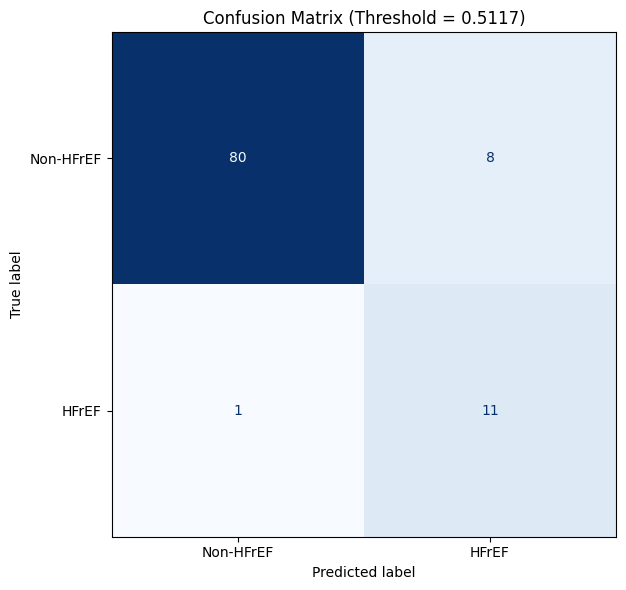

In [6]:
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, classification_report, ConfusionMatrixDisplay

# load the best saved weights
ecg_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device, weights_only=True))
ecg_model.eval()

# gather predictions on validation set
all_labels = []
all_preds = []
with torch.no_grad():
    for ecg, labels in val_loader:
        ecg = ecg.to(device)
        preds = torch.sigmoid(ecg_model(ecg))
        all_labels.extend(labels.cpu().numpy().ravel())
        all_preds.extend(preds.cpu().numpy().ravel())

# calculate optimal threshold (F1-Score)
precisions, recalls, thresholds_pr = precision_recall_curve(all_labels, all_preds)

# calculate F1 for all thresholds (adding 1e-8 to avoid division by zero)
f1_scores = (2 * precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = float(thresholds_pr[optimal_idx])

print(f"Optimal Probability Cutoff: {optimal_threshold:.4f}")
print(f"Max F1-Score: {f1_scores[optimal_idx]:.4f}")

# confusion matrix
binary_preds = (np.array(all_preds) >= optimal_threshold).astype(int)
cm = confusion_matrix(all_labels, binary_preds, labels=[0, 1])
print("\nClassification Report:")
print(classification_report(all_labels, binary_preds, labels=[0, 1], target_names=['Non-HFrEF', 'HFrEF'], zero_division=0))

# ROC Curve data
fpr, tpr, thresholds_roc = roc_curve(all_labels, all_preds)

# plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve (AUROC)
axes[0].plot(fpr, tpr, color='blue', lw=2)
axes[0].plot([0, 1], [0, 1], color='black', linestyle='--')
axes[0].set_xlabel('False Positive Rate (False Alarms)')
axes[0].set_ylabel('True Positive Rate (Caught Cases)')
axes[0].set_title('ROC Curve')

# Precision-Recall Curve (AUPRC)
axes[1].plot(recalls[:-1], precisions[:-1], color='green', lw=2)
# Mark the optimal threshold on the PR curve
axes[1].plot(recalls[optimal_idx], precisions[optimal_idx], marker='o', markersize=8, color="red", label="Optimal Threshold")
axes[1].set_xlabel('Recall (Caught Cases)')
axes[1].set_ylabel('Precision (Accuracy of Alarms)')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

print('Confusion Matrix:')
print(cm)

# Confusion Matrix (separate figure for readability)
fig_cm, ax_cm = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non-HFrEF', 'HFrEF']
)
disp.plot(ax=ax_cm, cmap='Blues', colorbar=False, values_format='d')
ax_cm.set_title(f'Confusion Matrix (Threshold = {optimal_threshold:.4f})')
plt.tight_layout()
plt.show()

In [7]:
# save the settings and threshold next to the model
experiment = {
    'model_config': model_config,
    'channel_order': list(CHANNEL_ORDER),
    'ecg_sample_rate': ECG_FS,
    'ecg_samples': ECG_SAMPLES,
    'ecg_bandpass_hz': [0.5, 40.0],
    'normalization': 'per-channel z-score',
    'seed': SEED,
    'validation_fold': VALIDATION_FOLD,
    'threshold': optimal_threshold,
    'focal_alpha': focal_alpha,
    'focal_gamma': 2.0,
    'learning_rate': learning_rate,
    'weight_decay': weight_decay,
    'batch_size': batch_size,
    'max_epochs': num_epochs,
    'patience': patience,
    'best_epoch': int(history.loc[history['val_auroc'].idxmax(), 'epoch']),
    'train_patient_ids': train_df['Patient_ID'].tolist(),
    'validation_patient_ids': val_df['Patient_ID'].tolist(),
}
with open(MODEL_SAVE_PATH.replace('.pt', '.json'), 'w') as f:
    json.dump(experiment, f, indent=2)

## Observations on the results:
These are the results from the old single-channel model. The old split could put channels from one patient in both sets, so we need a new run for the 4-channel model.

### Experiment 1: 
With 10 Epochs, Segmentation, BCEWithLogitsLoss with positive weight 7.3

- The model learns meaningful signal: the validation **AUROC reaches 0.6858**, which is better than random (0.50) but still indicates only moderate class separation. The best **AUPRC is 0.2836**, so performance remains challenging for the minority HFrEF class. Max F1-score is **0.3279** at a probability threshold of **0.5452**.
- The cutoff **0.5452** is not a medical threshold. It was selected by testing the validation predictions at different probability thresholds and choosing the one with the highest **F1-score (0.3279)**, balancing precision and recall.
- At this cutoff, HFrEF recall is about **64%**, meaning the model catches around 64% of HFrEF segments. HFrEF precision is only **22%**, meaning many positive predictions are false alarms. Because the validation set is imbalanced (330 HFrEF vs 2070 Normal), accuracy alone is not very informative.
- The **ROC curve** shows the trade-off between sensitivity (TPR) and false-positive rate across thresholds. The **Precision-Recall curve** is especially useful here because HFrEF is the minority class: it shows how much precision must be sacrificed to obtain higher recall.

#### Better workflow / What to improve next

- Choose the threshold based on the intended application rather than automatically optimizing F1. For screening, for example, a higher recall may be more important than precision.
- Evaluate performance at the **patient/record level** when multiple segments come from the same record, rather than treating every segment as an independent clinical prediction.
- For the next iterations, focus on improving minority-class discrimination and inspect the PR curve together with recall, precision, F1, AUROC, and AUPRC rather than relying on accuracy alone.

#### Experiment 2: 

With 50 Epochs, removing segmentation, Focal Loss with alpha=0.88 and gamma=2.0

- Tracking the epoch number with the best validation AUROC, the model didn't improve much over the previous experiment, as it only improved with the increase in epochs. The best **AUROC is 0.6995** and Max F1-score is **0.35** with a probability threshold of **0.5895**. Performance remains challenging for the minority HFrEF class.
- Segmentation should be reintroduced as it may help the model learn better features, and it can be used to aggregate predictions at the record level.

## Using The Test Set
- It should follow the same preprocessing steps as the training/validation data.
- This is now done in the preprocessing notebook. Here, we only load the saved files.

In [8]:
TEST_PROCESSED_DIR = os.path.join(PROJECT_DIR, 'data/processed/patient_4ch/test')
TEST_METADATA_PATH = os.path.join(TEST_PROCESSED_DIR, 'processed_metadata.csv')

if not os.path.isfile(TEST_METADATA_PATH):
    raise FileNotFoundError('Run the test preprocessing section in 1_preprocessing.ipynb first.')
test_metadata = pd.read_csv(TEST_METADATA_PATH, dtype={'Patient_ID': str})

print("Test label columns:")
print(test_metadata.columns.tolist())

print("\nFirst rows:")
print(test_metadata.head())

print("\nShape:")
print(test_metadata.shape)

# make sure no test patient was used in training or validation
assert test_metadata['Patient_ID'].is_unique
assert test_metadata['Fold'].eq(-1).all()
assert set(metadata['Patient_ID']).isdisjoint(test_metadata['Patient_ID'])

print("Test subjects:")
print(test_metadata['Label'].value_counts().sort_index())

Test label columns:
['Patient_ID', 'LVEF', 'Label', 'Fold', 'Channel_Order', 'Num_Channels', 'APEX_Record_ID', 'LLSB_Record_ID', 'LUSB_Record_ID', 'RUSB_Record_ID', 'ECG_File', 'PCG_File', 'ECG_Samples', 'PCG_Samples']

First rows:
   Patient_ID  LVEF  Label  Fold        Channel_Order  Num_Channels  \
0  1011486422  0.40      1    -1  APEX|LLSB|LUSB|RUSB             4   
1  2024031801  0.58      0    -1  APEX|LLSB|LUSB|RUSB             4   
2  2024031802  0.61      0    -1  APEX|LLSB|LUSB|RUSB             4   
3  2024031803  0.61      0    -1  APEX|LLSB|LUSB|RUSB             4   
4  2024031804  0.62      0    -1  APEX|LLSB|LUSB|RUSB             4   

    APEX_Record_ID   LLSB_Record_ID   LUSB_Record_ID   RUSB_Record_ID  \
0  1011486422_APEX  1011486422_LLSB  1011486422_LUSB  1011486422_RUSB   
1  2024031801_APEX  2024031801_LLSB  2024031801_LUSB  2024031801_RUSB   
2  2024031802_APEX  2024031802_LLSB  2024031802_LUSB  2024031802_RUSB   
3  2024031803_APEX  2024031803_LLSB  2024031803_L

### Create Dataset

In [9]:
# load one saved 4-channel ECG tensor for each test patient
test_dataset = ProcessedCardioDataset(test_metadata, TEST_PROCESSED_DIR, modality='ecg')

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print(f"Test patients: {len(test_dataset)}")
print(f"Test batches: {len(test_loader)}")

Test patients: 120
Test batches: 8


## Evaluate on Test Set

In [10]:
ecg_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device, weights_only=True))

ecg_model.eval()

test_labels = []
test_preds = []

with torch.no_grad():

    for ecg, labels in test_loader:

        ecg = ecg.to(device)

        outputs = ecg_model(ecg)
        preds = torch.sigmoid(outputs)

        test_labels.extend(labels.cpu().numpy().ravel())
        test_preds.extend(preds.cpu().numpy().ravel())

test_labels = np.array(test_labels)
test_preds = np.array(test_preds)

assert len(test_preds) == len(test_metadata)

print(f"Optimal threshold: {optimal_threshold}")

Optimal threshold: 0.511748731136322


## Test Results

Frozen threshold: 0.5117
Test AUROC:       0.9983
Test AUPRC:       0.9667

Classification Report:
              precision    recall  f1-score   support

   Non-HFrEF     1.0000    0.9652    0.9823       115
       HFrEF     0.5556    1.0000    0.7143         5

    accuracy                         0.9667       120
   macro avg     0.7778    0.9826    0.8483       120
weighted avg     0.9815    0.9667    0.9711       120


Confusion Matrix:


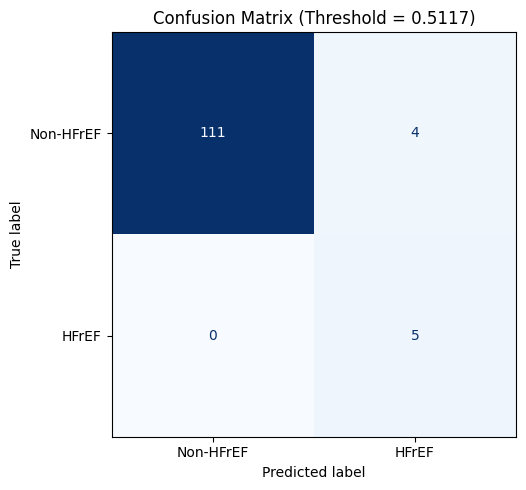

F1-Score:          0.7143
Balanced Accuracy: 0.9826
Sensitivity:       1.0000
Specificity:       0.9652


In [11]:
test_auroc = roc_auc_score(test_labels, test_preds)
test_auprc = average_precision_score(test_labels, test_preds)
test_binary_preds = (test_preds >= optimal_threshold).astype(int)
test_cm = confusion_matrix(test_labels, test_binary_preds, labels=[0, 1])

print(f"Frozen threshold: {optimal_threshold:.4f}")
print(f"Test AUROC:       {test_auroc:.4f}")
print(f"Test AUPRC:       {test_auprc:.4f}")

print("\nClassification Report:")
print(classification_report(test_labels, test_binary_preds, labels=[0, 1], target_names=['Non-HFrEF', 'HFrEF'], digits=4, zero_division=0))

fig, ax_cm = plt.subplots(figsize=(6, 5))

print("\nConfusion Matrix:")
disp = ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=['Non-HFrEF', 'HFrEF']
)
disp.plot(ax=ax_cm, cmap='Blues', colorbar=False, values_format='d')
ax_cm.set_title(f'Confusion Matrix (Threshold = {optimal_threshold:.4f})')

plt.tight_layout()
plt.show()

# a few more metrics at the same threshold
from sklearn.metrics import f1_score, balanced_accuracy_score

tn, fp, fn, tp = test_cm.ravel()
print(f"F1-Score:          {f1_score(test_labels, test_binary_preds, zero_division=0):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(test_labels, test_binary_preds):.4f}")
print(f"Sensitivity:       {tp / (tp + fn) if tp + fn else float('nan'):.4f}")
print(f"Specificity:       {tn / (tn + fp) if tn + fp else float('nan'):.4f}")

# save one prediction for each patient
test_results_df = test_metadata[['Patient_ID', 'Label']].copy()
test_results_df['Probability'] = test_preds
test_results_df['Prediction'] = test_binary_preds
test_results_df.to_csv(MODEL_SAVE_PATH.replace('.pt', '.test_predictions.csv'), index=False)